**Import libraries**

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.io import mmread # read mtx sparse matrices
from scipy import sparse # handle sparse

In [2]:
# scanpy settings

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80)
sc.settings.figdir = "figures"
os.makedirs("figures", exist_ok=True)


# plotting style
sns.set(style="whitegrid")


**Load Matrix, Genes and Cells file**

In [3]:
matrix_path = "/Users/dishanaudiyal/Desktop/bioinfobyte/scRNA/data_GSE118614/GSE118614_Smart_aggregate.mtx"

In [4]:
genes_path = "/Users/dishanaudiyal/Desktop/bioinfobyte/scRNA/data_GSE118614/GSE118614_Smart_genes.tsv"

In [5]:
cells_path = "/Users/dishanaudiyal/Desktop/bioinfobyte/scRNA/data_GSE118614/GSE118614_Smart_cells.tsv"

**Read matrix as scipy.sparse**

*- mmread returns rows x cols -> no need to tranpose since already cells x genes*
*- convert it to sparse csr format*

In [6]:
matrix = mmread(matrix_path)
print("og matrix:" , matrix.shape)

X = sparse.csr_matrix(matrix)
print("CSR matrix:", X.shape)

og matrix: (747, 28446)
CSR matrix: (747, 28446)


**Reading genes and cells file**

*- the genes and cells .tsv files have inconsistent columns*
*- reading as single-column text helps fix the error*

In [7]:
genes = pd.read_csv(genes_path,sep ="\t",header=None,skiprows =1)

In [8]:
# renaming the columns

genes = genes.rename(columns= {0:"gene_symbol"})

genes.head()

,gene_symbol,1,2,3,4,5,6
0,ENSMUSG00000000001.4,Gnai3,chr3:108107279-108146146,354,1.233507,47.389558,False
1,ENSMUSG00000000003.12,Pbsn,chrX:77837900-77853623,0,0.000000,0.000000,False
2,ENSMUSG00000000028.11,Cdc45,chr16:18780446-18835261,205,0.783493,27.443106,False
3,ENSMUSG00000000031.12,H19,chr7:142575528-142578143,95,0.167549,12.717537,True
4,ENSMUSG00000000037.13,Scml2,chrX:161117192-161258213,43,0.042965,5.756359,False


In [9]:
print("genes shape: ",genes.shape)

genes shape:  (28446, 7)


In [10]:
cells = pd.read_csv(cells_path,sep="\t",header=None,skiprows =1)

In [11]:
cells = cells.rename(columns={0: "cell_id"})

cells.head()

,cell_id,1,2,3,4,5,6,7,8,9
0,q1_0,E14_C01,E14,E14_Plate1,3321,14732.0,6.327558,7.145755,38,Neurogenic Cells
1,q2_0,E14_C02,E14,E14_Plate1,3445,15112.0,43.731342,2.881545,37,Amacrine Cells
2,q3_0,E14_C03,E14,E14_Plate1,3135,13932.0,25.511027,24.931069,31,Early RPCs
3,q4_0,E14_C04,E14,E14_Plate1,3290,14392.0,20.545980,-1.719829,14,Retinal Ganglion Cells
4,q5_0,E14_C05,E14,E14_Plate1,1960,9116.0,24.906142,29.860198,26,Early RPCs


In [12]:
print(cells.shape)

(747, 10)


**Building AnnData object**

In [13]:
adata = sc.AnnData(
    X= X,
    obs=cells,
    var=genes
)

/opt/anaconda3/envs/scRna/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/scRna/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [14]:
print(adata)

AnnData object with n_obs × n_vars = 747 × 28446
    obs: 'cell_id', 1, 2, 3, 4, 5, 6, 7, 8, 9
    var: 'gene_symbol', 1, 2, 3, 4, 5, 6


*setting first column of cell and genes as cell id and gene names respectively using indices*

In [15]:
adata.obs_names = cells.iloc[:,0].astype(str)
adata.var_names = genes.iloc[:,0].astype(str)

*ensure unique names*

In [16]:
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [17]:
print(adata)

print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

AnnData object with n_obs × n_vars = 747 × 28446
    obs: 'cell_id', 1, 2, 3, 4, 5, 6, 7, 8, 9
    var: 'gene_symbol', 1, 2, 3, 4, 5, 6
Cells: 747
Genes: 28446


In [18]:
adata.obs.head()

,cell_id,1,2,3,4,5,6,7,8,9
cell_id,,,,,,,,,,
q1_0,q1_0,E14_C01,E14,E14_Plate1,3321,14732.0,6.327558,7.145755,38,Neurogenic Cells
q2_0,q2_0,E14_C02,E14,E14_Plate1,3445,15112.0,43.731342,2.881545,37,Amacrine Cells
q3_0,q3_0,E14_C03,E14,E14_Plate1,3135,13932.0,25.511027,24.931069,31,Early RPCs
q4_0,q4_0,E14_C04,E14,E14_Plate1,3290,14392.0,20.545980,-1.719829,14,Retinal Ganglion Cells
q5_0,q5_0,E14_C05,E14,E14_Plate1,1960,9116.0,24.906142,29.860198,26,Early RPCs


In [19]:
adata.var.head()

,gene_symbol,1,2,3,4,5,6
gene_symbol,,,,,,,
ENSMUSG00000000001.4,ENSMUSG00000000001.4,Gnai3,chr3:108107279-108146146,354,1.233507,47.389558,False
ENSMUSG00000000003.12,ENSMUSG00000000003.12,Pbsn,chrX:77837900-77853623,0,0.000000,0.000000,False
ENSMUSG00000000028.11,ENSMUSG00000000028.11,Cdc45,chr16:18780446-18835261,205,0.783493,27.443106,False
ENSMUSG00000000031.12,ENSMUSG00000000031.12,H19,chr7:142575528-142578143,95,0.167549,12.717537,True
ENSMUSG00000000037.13,ENSMUSG00000000037.13,Scml2,chrX:161117192-161258213,43,0.042965,5.756359,False


**QC**

In [20]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

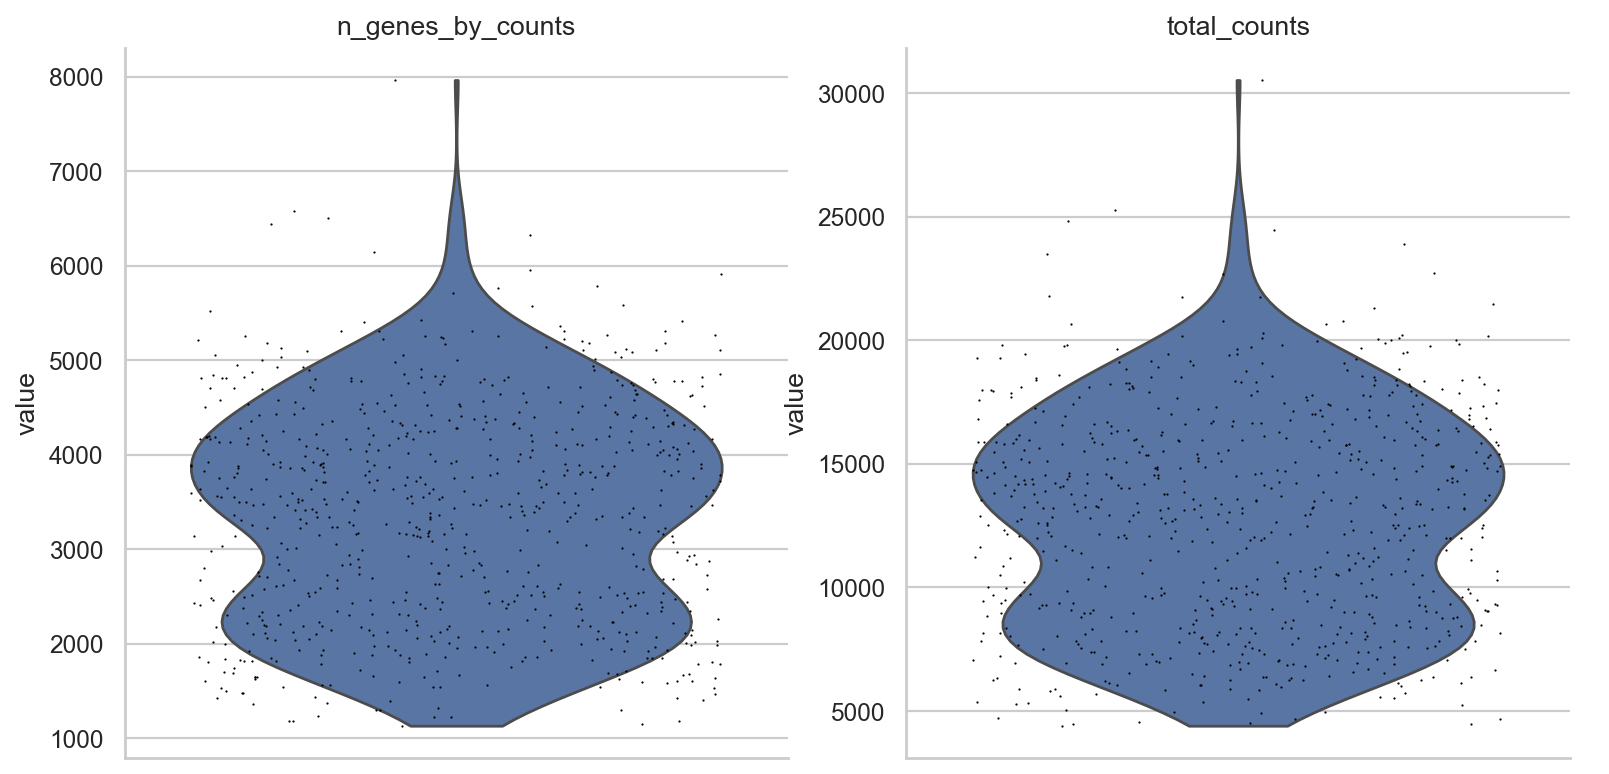

In [21]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts'],
    jitter=0.4,
    multi_panel=True,
    save = "_plt.png"
    
)

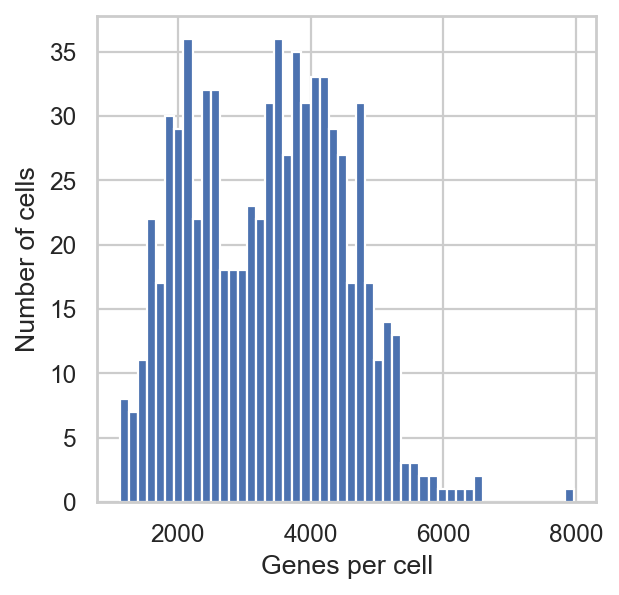

In [24]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.hist(adata.obs['n_genes_by_counts'], bins=50)
plt.xlabel("Genes per cell")
plt.ylabel("Number of cells")
plt.show()
fig.savefig("figures/gene_count.png")

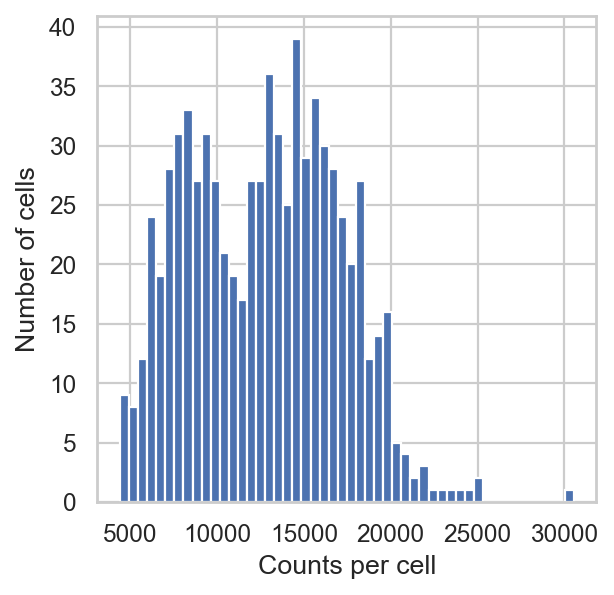

In [25]:
fig = plt.figure()

plt.hist(adata.obs['total_counts'], bins=50)
plt.xlabel("Counts per cell")
plt.ylabel("Number of cells")
plt.savefig("figures/total_counts.png")
plt.show()

**Filtering**

to remove doublets

In [26]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

filtered out 11687 genes that are detected in less than 3 cells


In [27]:
adata = adata[adata.obs['n_genes_by_counts'] < 6000, :]

**Normalization**

*- normalizes each cell to 10k counts*

In [28]:
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:00)


/opt/anaconda3/envs/scRna/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


**log tranform**

*log(1 + counts): stabilizes variance, makes gene expression distributions more normal*

In [29]:
sc.pp.log1p(adata)

**Identify highly variable genes**

In [30]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [31]:
adata.var['highly_variable'].sum()

2000

**Visualize HVG**

*grey = low variance genes,
red = highly variable genes -
These genes drive cell-type differences*

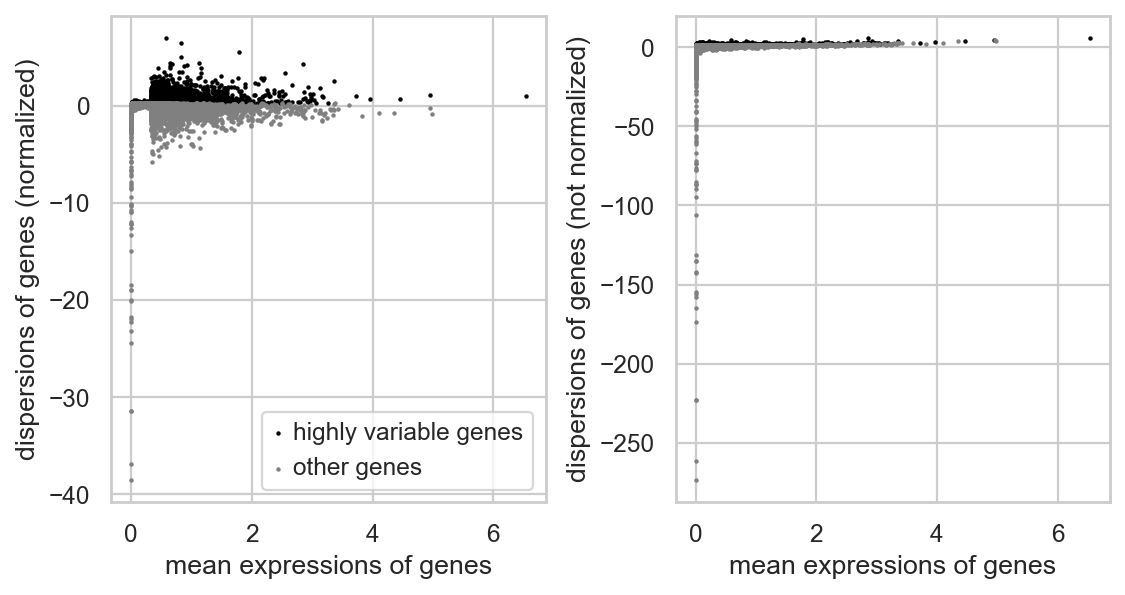

In [33]:
sc.pl.highly_variable_genes(adata, save = "_hvg.png")

*subset highly variable genes*

In [34]:
adata = adata[:, adata.var.highly_variable]

In [35]:
print(adata)

View of AnnData object with n_obs × n_vars = 741 × 2000
    obs: 'cell_id', 1, 2, 3, 4, 5, 6, 7, 8, 9, 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'gene_symbol', 1, 2, 3, 4, 5, 6, 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'


**Scale the data**

*center genes to mean = 0
variance = 1*

In [36]:
sc.pp.scale(adata, max_value=10)

/opt/anaconda3/envs/scRna/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/scRna/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


**Run PCA**

In [37]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:00:00)


*plt variance*

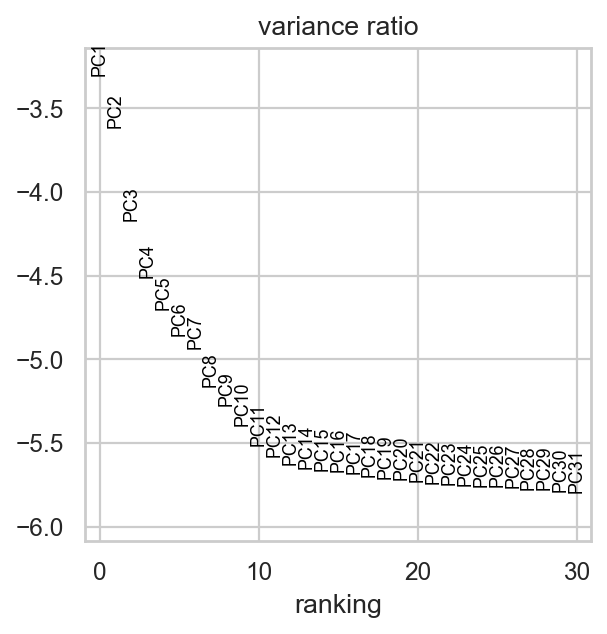

In [38]:
sc.pl.pca_variance_ratio(adata, log=True, save="_pca_variance.png")

**Build neighbor graph**

In [39]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

computing neighbors
    using 'X_pca' with n_pcs = 30


/opt/anaconda3/envs/scRna/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)


**Compute UMAP**

In [40]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)


**Cluster cells (Leiden)**

In [41]:
sc.tl.leiden(adata, resolution=0.5)

running Leiden clustering
    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


/var/folders/_p/vpywfxbx48g9ssmqwb6xrm6c0000gn/T/ipykernel_19764/1771924308.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


*check clusters*

In [42]:
adata.obs['leiden'].value_counts()

leiden
0    166
1    140
2    120
3    115
4     79
5     67
6     54
Name: count, dtype: int64

**VISUALIZE CLUSTERS**

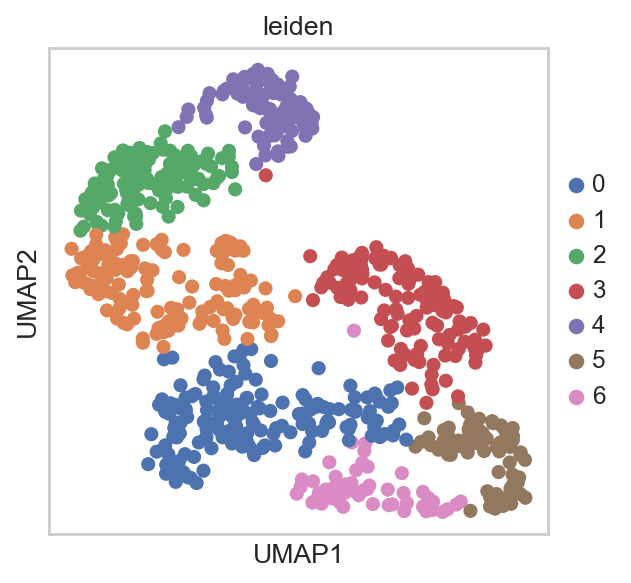

In [43]:
sc.pl.umap(adata, color='leiden',save="_leiden_umap.png")